# Thompson Sampling: Bayesian Multi-Armed Bandit

Dieses Notebook demonstriert die A/B-Test-gestützte Bayes'sche Optimierung mit Thompson Sampling.

Wir implementieren ein System, das:
- Mehrere Varianten (A, B, C) mit unterschiedlichen wahren Erfolgswahrscheinlichkeiten testet
- Die Beta-Verteilung als Prior verwendet
- Thompson Sampling zur Auswahl der Varianten nutzt
- Die Posterior-Verteilungen kontinuierlich aktualisiert
- Die Ergebnisse über die Zeit visualisiert
- **Trackt, ab welcher Iteration eine Variante mit konfigurierbarer Konfidenz (z.B. 95%) die beste ist**

In [1]:
# Import benötigter Bibliotheken
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import seaborn as sns
from typing import List, Dict, Tuple

# Plotting-Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Implementierung der Bayesian Bandit Klasse

Die Klasse implementiert Thompson Sampling mit Beta-Binomial Konjugation.

In [2]:
class BayesianBandit:
    """
    Bayesian Multi-Armed Bandit mit Thompson Sampling.
    
    Jede Variante (Arm) wird durch eine Beta-Verteilung modelliert.
    Thompson Sampling wählt den Arm basierend auf Samples aus den Posterior-Verteilungen.
    """
    
    def __init__(self, n_arms: int, arm_names: List[str] = None, 
                 alpha_prior: float = 1.0, beta_prior: float = 1.0):
        """
        Initialisiert den Bayesian Bandit.
        
        Parameters:
        -----------
        n_arms : int
            Anzahl der Varianten (Arms)
        arm_names : List[str], optional
            Namen der Varianten (z.B. ['A', 'B', 'C'])
        alpha_prior : float
            Alpha-Parameter der Beta-Prior-Verteilung (Standard: 1.0 für uniform prior)
        beta_prior : float
            Beta-Parameter der Beta-Prior-Verteilung (Standard: 1.0 für uniform prior)
        """
        self.n_arms = n_arms
        self.arm_names = arm_names if arm_names else [f"Arm {i}" for i in range(n_arms)]
        
        # Beta-Parameter für jede Variante (alpha = Erfolge, beta = Misserfolge)
        self.alpha = np.full(n_arms, alpha_prior)
        self.beta = np.full(n_arms, beta_prior)
        
        # Tracking
        self.total_pulls = np.zeros(n_arms)
        self.total_rewards = np.zeros(n_arms)
        
        # Historie für Visualisierung
        self.history = {
            'iteration': [],
            'selected_arm': [],
            'reward': [],
            'alpha': [],
            'beta': []
        }
    
    def select_arm(self) -> int:
        """
        Wählt einen Arm mittels Thompson Sampling.
        
        Returns:
        --------
        int : Index des ausgewählten Arms
        """
        # Ziehe eine Stichprobe aus der Posterior-Verteilung jedes Arms
        samples = np.random.beta(self.alpha, self.beta)
        
        # Wähle den Arm mit dem höchsten Sample-Wert
        return np.argmax(samples)
    
    def update(self, arm: int, reward: int):
        """
        Aktualisiert die Posterior-Verteilung nach Beobachtung eines Rewards.
        
        Parameters:
        -----------
        arm : int
            Index des gezogenen Arms
        reward : int
            Beobachteter Reward (1 = Erfolg, 0 = Misserfolg)
        """
        # Update Beta-Parameter
        if reward == 1:
            self.alpha[arm] += 1
            self.total_rewards[arm] += 1
        else:
            self.beta[arm] += 1
        
        self.total_pulls[arm] += 1
    
    def record_history(self, iteration: int, arm: int, reward: int):
        """Speichert den aktuellen Zustand für spätere Visualisierung."""
        self.history['iteration'].append(iteration)
        self.history['selected_arm'].append(arm)
        self.history['reward'].append(reward)
        self.history['alpha'].append(self.alpha.copy())
        self.history['beta'].append(self.beta.copy())
    
    def get_posterior_mean(self) -> np.ndarray:
        """
        Berechnet den Posterior-Mittelwert (Erwartungswert) für jeden Arm.
        
        Returns:
        --------
        np.ndarray : Posterior-Mittelwerte
        """
        return self.alpha / (self.alpha + self.beta)
    
    def get_posterior_std(self) -> np.ndarray:
        """
        Berechnet die Posterior-Standardabweichung für jeden Arm.
        
        Returns:
        --------
        np.ndarray : Posterior-Standardabweichungen
        """
        mean = self.get_posterior_mean()
        n = self.alpha + self.beta
        return np.sqrt(mean * (1 - mean) / (n + 1))
    
    def get_probability_best(self, n_samples: int = 10000) -> np.ndarray:
        """
        Schätzt die Wahrscheinlichkeit, dass jeder Arm der beste ist.
        
        Parameters:
        -----------
        n_samples : int
            Anzahl der Monte-Carlo-Samples
        
        Returns:
        --------
        np.ndarray : Wahrscheinlichkeiten für jeden Arm
        """
        samples = np.random.beta(
            self.alpha[:, np.newaxis], 
            self.beta[:, np.newaxis], 
            size=(self.n_arms, n_samples)
        )
        best_arm = np.argmax(samples, axis=0)
        return np.bincount(best_arm, minlength=self.n_arms) / n_samples
    
    def print_summary(self):
        """Gibt eine Zusammenfassung des aktuellen Zustands aus."""
        print("=" * 70)
        print("Bayesian Bandit - Zusammenfassung")
        print("=" * 70)
        
        posterior_mean = self.get_posterior_mean()
        posterior_std = self.get_posterior_std()
        prob_best = self.get_probability_best()
        
        for i in range(self.n_arms):
            print(f"\n{self.arm_names[i]}:")
            print(f"  Gezogen: {int(self.total_pulls[i])} mal ({self.total_pulls[i]/self.total_pulls.sum()*100:.1f}%)")
            print(f"  Erfolge: {int(self.total_rewards[i])}")
            print(f"  Beobachtete Rate: {self.total_rewards[i]/max(1, self.total_pulls[i]):.4f}")
            print(f"  Posterior μ: {posterior_mean[i]:.4f} ± {posterior_std[i]:.4f}")
            print(f"  Beta({self.alpha[i]:.1f}, {self.beta[i]:.1f})")
            print(f"  P(beste Variante): {prob_best[i]:.2%}")
        
        print("\n" + "=" * 70)

## 2. Simulations-Funktion

Diese Funktion simuliert das Bandit-Problem mit bekannten wahren Erfolgswahrscheinlichkeiten und trackt, wann die konfigurierbare Konfidenz-Schwelle erreicht wird.

In [3]:
def simulate_bandit(bandit: BayesianBandit, 
                   true_probs: np.ndarray, 
                   n_iterations: int,
                   random_seed: int = None,
                   confidence_threshold: float = 0.95,
                   check_interval: int = 50) -> Tuple[BayesianBandit, Dict]:
    """
    Simuliert das Bandit-Problem mit bekannten wahren Erfolgswahrscheinlichkeiten.
    
    Parameters:
    -----------
    bandit : BayesianBandit
        Die Bandit-Instanz
    true_probs : np.ndarray
        Wahre Erfolgswahrscheinlichkeiten für jeden Arm
    n_iterations : int
        Anzahl der Iterationen (Besucher)
    random_seed : int, optional
        Seed für Reproduzierbarkeit
    confidence_threshold : float, optional
        Wahrscheinlichkeitsschwelle für "beste Variante" (Standard: 0.95)
    check_interval : int, optional
        Intervall für Überprüfung der Wahrscheinlichkeiten (Standard: 50)
    
    Returns:
    --------
    Tuple[BayesianBandit, Dict] : (Bandit-Instanz, Tracking-Informationen)
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Tracking für Wahrscheinlichkeiten über Zeit
    prob_best_history = []
    iterations_checked = []
    threshold_reached = None  # (iteration, arm) wenn Schwelle erreicht
    
    for i in range(n_iterations):
        # Wähle einen Arm mittels Thompson Sampling
        selected_arm = bandit.select_arm()
        
        # Simuliere das Ergebnis basierend auf der wahren Wahrscheinlichkeit
        reward = 1 if np.random.random() < true_probs[selected_arm] else 0
        
        # Update die Posterior-Verteilung
        bandit.update(selected_arm, reward)
        
        # Speichere für Visualisierung
        bandit.record_history(i, selected_arm, reward)
        
        # Überprüfe regelmäßig die Wahrscheinlichkeiten
        if (i + 1) % check_interval == 0 or i == n_iterations - 1:
            prob_best = bandit.get_probability_best(n_samples=5000)
            prob_best_history.append(prob_best.copy())
            iterations_checked.append(i + 1)
            
            # Prüfe, ob Schwelle erreicht wurde (nur beim ersten Mal)
            if threshold_reached is None:
                best_arm_idx = np.argmax(prob_best)
                if prob_best[best_arm_idx] >= confidence_threshold:
                    threshold_reached = (i + 1, best_arm_idx)
    
    tracking_info = {
        'prob_best_history': np.array(prob_best_history),
        'iterations_checked': np.array(iterations_checked),
        'threshold_reached': threshold_reached,
        'confidence_threshold': confidence_threshold
    }
    
    return bandit, tracking_info

## 3. Analyse- und Ausgabefunktionen

Funktionen zur Analyse, wann die Konfidenz-Schwelle erreicht wurde.

In [4]:
def print_threshold_analysis(bandit: BayesianBandit, tracking_info: Dict):
    """
    Gibt eine Analyse aus, wann die Wahrscheinlichkeitsschwelle erreicht wurde.
    """
    threshold = tracking_info['confidence_threshold']
    threshold_reached = tracking_info['threshold_reached']
    
    print("\n" + "="*70)
    print(f"ANALYSE: Wann wurde die {threshold:.0%}-Schwelle erreicht?")
    print("="*70)
    
    if threshold_reached is not None:
        iter_reached, arm_reached = threshold_reached
        arm_name = bandit.arm_names[arm_reached]
        
        print(f"\n✓ Die Schwelle wurde erreicht!")
        print(f"  Iteration: {iter_reached}")
        print(f"  Beste Variante: {arm_name}")
        print(f"  \n  → Ab Iteration {iter_reached} kann man mit {threshold:.0%} Konfidenz sagen:")
        print(f"     \"{arm_name} ist die beste Variante\"")
        
        # Aktuelle Wahrscheinlichkeiten
        final_probs = bandit.get_probability_best()
        print(f"\n  Finale Wahrscheinlichkeiten:")
        for i, name in enumerate(bandit.arm_names):
            marker = " ← BESTE" if i == arm_reached else ""
            print(f"    {name}: {final_probs[i]:.2%}{marker}")
    else:
        print(f"\n✗ Die {threshold:.0%}-Schwelle wurde nicht erreicht.")
        print(f"  Es sind möglicherweise mehr Iterationen erforderlich.")
        
        # Zeige aktuelle Wahrscheinlichkeiten
        final_probs = bandit.get_probability_best()
        best_arm = np.argmax(final_probs)
        print(f"\n  Aktuelle Wahrscheinlichkeiten (nach allen Iterationen):")
        for i, name in enumerate(bandit.arm_names):
            marker = " ← höchste" if i == best_arm else ""
            print(f"    {name}: {final_probs[i]:.2%}{marker}")
    
    print("\n" + "="*70)

## 4. Visualisierungs-Funktionen

Verschiedene Funktionen zur Visualisierung der Ergebnisse über die Zeit.

In [5]:
def plot_probability_best_over_time(bandit: BayesianBandit, tracking_info: Dict):
    """
    Zeigt die Evolution der P(beste Variante) über die Zeit mit Schwellenwert.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    prob_best_history = tracking_info['prob_best_history']
    iterations_checked = tracking_info['iterations_checked']
    threshold = tracking_info['confidence_threshold']
    threshold_reached = tracking_info['threshold_reached']
    
    colors = plt.cm.Set2(range(bandit.n_arms))
    
    # Plotte P(beste Variante) für jeden Arm
    for i in range(bandit.n_arms):
        ax.plot(iterations_checked, prob_best_history[:, i] * 100, 
               label=bandit.arm_names[i], color=colors[i], linewidth=2, marker='o', markersize=4)
    
    # Schwellenwert-Linie
    ax.axhline(threshold * 100, color='red', linestyle='--', linewidth=2, 
              label=f'Schwellenwert ({threshold:.0%})', alpha=0.7)
    
    # Markiere, wann Schwelle erreicht wurde
    if threshold_reached is not None:
        iter_reached, arm_reached = threshold_reached
        prob_at_threshold = prob_best_history[
            np.where(iterations_checked == iter_reached)[0][0], arm_reached
        ]
        ax.scatter([iter_reached], [prob_at_threshold * 100], 
                  color='red', s=200, zorder=5, marker='*',
                  label=f'Schwelle erreicht (Iteration {iter_reached})')
        ax.axvline(iter_reached, color='red', linestyle=':', alpha=0.5)
    
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('P(beste Variante) [%]', fontsize=11)
    ax.set_title(f'Wahrscheinlichkeit "beste Variante" über Zeit\n(Schwelle: {threshold:.0%})', 
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.show()


def plot_posterior_evolution(bandit: BayesianBandit, true_probs: np.ndarray, 
                            snapshots: List[int] = None):
    """
    Zeigt die Evolution der Posterior-Verteilungen über die Zeit.
    """
    if snapshots is None:
        n_iter = len(bandit.history['iteration'])
        snapshots = [int(n_iter * p) for p in [0.1, 0.25, 0.5, 1.0]]
    
    n_snapshots = len(snapshots)
    fig, axes = plt.subplots(1, n_snapshots, figsize=(5*n_snapshots, 4))
    
    if n_snapshots == 1:
        axes = [axes]
    
    x = np.linspace(0, 1, 1000)
    colors = plt.cm.Set2(range(bandit.n_arms))
    
    for idx, snapshot_iter in enumerate(snapshots):
        ax = axes[idx]
        
        if snapshot_iter > 0 and snapshot_iter <= len(bandit.history['iteration']):
            alpha_snapshot = bandit.history['alpha'][snapshot_iter - 1]
            beta_snapshot = bandit.history['beta'][snapshot_iter - 1]
        else:
            alpha_snapshot = bandit.alpha
            beta_snapshot = bandit.beta
        
        for i in range(bandit.n_arms):
            y = beta.pdf(x, alpha_snapshot[i], beta_snapshot[i])
            ax.plot(x, y, label=f'{bandit.arm_names[i]} (μ={alpha_snapshot[i]/(alpha_snapshot[i]+beta_snapshot[i]):.3f})', 
                   color=colors[i], linewidth=2)
            
            # Markiere wahre Wahrscheinlichkeit
            ax.axvline(true_probs[i], color=colors[i], linestyle='--', alpha=0.5, linewidth=1.5)
        
        ax.set_xlabel('Erfolgswahrscheinlichkeit p', fontsize=11)
        ax.set_ylabel('Dichte', fontsize=11)
        ax.set_title(f'Iteration {snapshot_iter}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_arm_selection_over_time(bandit: BayesianBandit):
    """
    Zeigt die kumulative Verteilung der Arm-Auswahlen über die Zeit.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    iterations = bandit.history['iteration']
    n_arms = bandit.n_arms
    colors = plt.cm.Set2(range(n_arms))
    
    # Kumulative Anzahl für jeden Arm
    cumulative_counts = np.zeros((len(iterations), n_arms))
    for i, arm in enumerate(bandit.history['selected_arm']):
        if i > 0:
            cumulative_counts[i] = cumulative_counts[i-1].copy()
        cumulative_counts[i, arm] += 1
    
    # Plot 1: Absolute Zahlen
    for i in range(n_arms):
        ax1.plot(iterations, cumulative_counts[:, i], label=bandit.arm_names[i], 
                color=colors[i], linewidth=2)
    ax1.set_xlabel('Iteration', fontsize=11)
    ax1.set_ylabel('Kumulative Anzahl Ziehungen', fontsize=11)
    ax1.set_title('Kumulative Arm-Auswahlen über Zeit', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Prozentuale Anteile
    total_counts = cumulative_counts.sum(axis=1, keepdims=True)
    proportions = np.divide(cumulative_counts, total_counts, 
                           where=total_counts!=0, out=np.zeros_like(cumulative_counts))
    
    for i in range(n_arms):
        ax2.plot(iterations, proportions[:, i] * 100, label=bandit.arm_names[i], 
                color=colors[i], linewidth=2)
    ax2.set_xlabel('Iteration', fontsize=11)
    ax2.set_ylabel('Anteil (%)', fontsize=11)
    ax2.set_title('Prozentuale Verteilung der Arm-Auswahlen', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 100])
    
    plt.tight_layout()
    plt.show()


def plot_posterior_means_over_time(bandit: BayesianBandit, true_probs: np.ndarray):
    """
    Zeigt die Evolution der Posterior-Mittelwerte mit Konfidenzintervallen.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    iterations = bandit.history['iteration']
    n_arms = bandit.n_arms
    colors = plt.cm.Set2(range(n_arms))
    
    # Berechne Posterior-Mittelwerte und Standardabweichungen über die Zeit
    means_over_time = np.zeros((len(iterations), n_arms))
    stds_over_time = np.zeros((len(iterations), n_arms))
    
    for idx, (alpha_vals, beta_vals) in enumerate(zip(bandit.history['alpha'], 
                                                       bandit.history['beta'])):
        means_over_time[idx] = alpha_vals / (alpha_vals + beta_vals)
        n_vals = alpha_vals + beta_vals
        stds_over_time[idx] = np.sqrt(means_over_time[idx] * (1 - means_over_time[idx]) / (n_vals + 1))
    
    for i in range(n_arms):
        # Plot Mittelwert
        ax.plot(iterations, means_over_time[:, i], label=bandit.arm_names[i], 
               color=colors[i], linewidth=2)
        
        # Plot Konfidenzintervall (± 1 Standardabweichung)
        ax.fill_between(iterations, 
                       means_over_time[:, i] - stds_over_time[:, i],
                       means_over_time[:, i] + stds_over_time[:, i],
                       color=colors[i], alpha=0.2)
        
        # Wahre Wahrscheinlichkeit als horizontale Linie
        ax.axhline(true_probs[i], color=colors[i], linestyle='--', 
                  alpha=0.5, linewidth=1.5)
    
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Geschätzte Erfolgswahrscheinlichkeit', fontsize=11)
    ax.set_title('Evolution der Posterior-Mittelwerte (± 1 SD)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()


def plot_cumulative_regret(bandit: BayesianBandit, true_probs: np.ndarray):
    """
    Zeigt den kumulativen Regret über die Zeit.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    best_prob = np.max(true_probs)
    iterations = bandit.history['iteration']
    
    cumulative_regret = []
    total_regret = 0
    
    for arm, reward in zip(bandit.history['selected_arm'], bandit.history['reward']):
        instant_regret = best_prob - true_probs[arm]
        total_regret += instant_regret
        cumulative_regret.append(total_regret)
    
    ax.plot(iterations, cumulative_regret, linewidth=2, color='darkred')
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Kumulativer Regret', fontsize=11)
    ax.set_title('Kumulativer Regret über Zeit\n(Differenz zum optimalen Arm)', 
                fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    avg_regret = total_regret / len(iterations)
    ax.axline((0, 0), slope=avg_regret, color='red', linestyle='--', 
             alpha=0.5, label=f'Ø Regret/Iteration: {avg_regret:.4f}')
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()


def create_full_visualization(bandit: BayesianBandit, true_probs: np.ndarray, 
                             tracking_info: Dict = None):
    """
    Erstellt eine vollständige Visualisierung aller Aspekte.
    """
    print("\n" + "="*70)
    print("VISUALISIERUNGEN")
    print("="*70 + "\n")
    
    # Neue Visualisierung zuerst: P(beste Variante) über Zeit
    if tracking_info is not None:
        print("1. Wahrscheinlichkeit \"beste Variante\" über Zeit")
        plot_probability_best_over_time(bandit, tracking_info)
    
    print("\n2. Evolution der Posterior-Verteilungen")
    plot_posterior_evolution(bandit, true_probs)
    
    print("\n3. Arm-Auswahlen über Zeit")
    plot_arm_selection_over_time(bandit)
    
    print("\n4. Posterior-Mittelwerte mit Konfidenzintervallen")
    plot_posterior_means_over_time(bandit, true_probs)
    
    print("\n5. Kumulativer Regret")
    plot_cumulative_regret(bandit, true_probs)

## 5. Beispiel: Drei Varianten A, B, C

Wir definieren drei Varianten mit unterschiedlichen wahren Erfolgswahrscheinlichkeiten:
- **Variante A**: 0.15 (15% Conversion)
- **Variante B**: 0.25 (25% Conversion) ← **BESTE VARIANTE**
- **Variante C**: 0.20 (20% Conversion)

Der Algorithmus soll diese Wahrscheinlichkeiten automatisch lernen und mehr Traffic zu Variante B lenken.

In [6]:
# Definiere die wahren Erfolgswahrscheinlichkeiten
true_probabilities = np.array([0.15, 0.25, 0.20])
arm_names = ['Variante A', 'Variante B', 'Variante C']

print("Wahre Erfolgswahrscheinlichkeiten:")
for name, prob in zip(arm_names, true_probabilities):
    print(f"  {name}: {prob:.1%}")
print(f"\nBeste Variante: {arm_names[np.argmax(true_probabilities)]} ({np.max(true_probabilities):.1%})")

Wahre Erfolgswahrscheinlichkeiten:
  Variante A: 15.0%
  Variante B: 25.0%
  Variante C: 20.0%

Beste Variante: Variante B (25.0%)


## 6. Simulation durchführen

Wir simulieren 2000 Besucher und beobachten, wie der Algorithmus lernt.

**Wichtig**: Die Konfidenz-Schwelle (Standard: 95%) ist konfigurierbar!

In [7]:
# Initialisiere den Bayesian Bandit
n_iterations = 2000
confidence_threshold = 0.95  # Konfigurierbar: 95% ist der Standard

bandit = BayesianBandit(n_arms=3, arm_names=arm_names)

print(f"Starte Simulation mit {n_iterations} Iterationen...")
print(f"Konfidenz-Schwelle: {confidence_threshold:.0%}\n")

# Führe die Simulation durch
bandit, tracking_info = simulate_bandit(
    bandit, 
    true_probabilities, 
    n_iterations, 
    random_seed=42,
    confidence_threshold=confidence_threshold,
    check_interval=50
)

print("Simulation abgeschlossen!\n")

# Zeige Zusammenfassung
bandit.print_summary()

# Zeige Schwellenwert-Analyse
print_threshold_analysis(bandit, tracking_info)

Starte Simulation mit 2000 Iterationen...
Konfidenz-Schwelle: 95%

Simulation abgeschlossen!

Bayesian Bandit - Zusammenfassung

Variante A:
  Gezogen: 162 mal (8.1%)
  Erfolge: 29
  Beobachtete Rate: 0.1790
  Posterior μ: 0.1829 ± 0.0301
  Beta(30.0, 134.0)
  P(beste Variante): 1.55%

Variante B:
  Gezogen: 1795 mal (89.8%)
  Erfolge: 457
  Beobachtete Rate: 0.2546
  Posterior μ: 0.2549 ± 0.0103
  Beta(458.0, 1339.0)
  P(beste Variante): 98.21%

Variante C:
  Gezogen: 43 mal (2.1%)
  Erfolge: 3
  Beobachtete Rate: 0.0698
  Posterior μ: 0.0889 ± 0.0420
  Beta(4.0, 41.0)
  P(beste Variante): 0.24%


ANALYSE: Wann wurde die 95%-Schwelle erreicht?

✓ Die Schwelle wurde erreicht!
  Iteration: 1000
  Beste Variante: Variante B
  
  → Ab Iteration 1000 kann man mit 95% Konfidenz sagen:
     "Variante B ist die beste Variante"

  Finale Wahrscheinlichkeiten:
    Variante A: 1.47%
    Variante B: 98.32% ← BESTE
    Variante C: 0.21%



## 7. Visualisierung der Ergebnisse

Jetzt visualisieren wir, wie der Algorithmus gelernt hat.


VISUALISIERUNGEN

1. Wahrscheinlichkeit "beste Variante" über Zeit


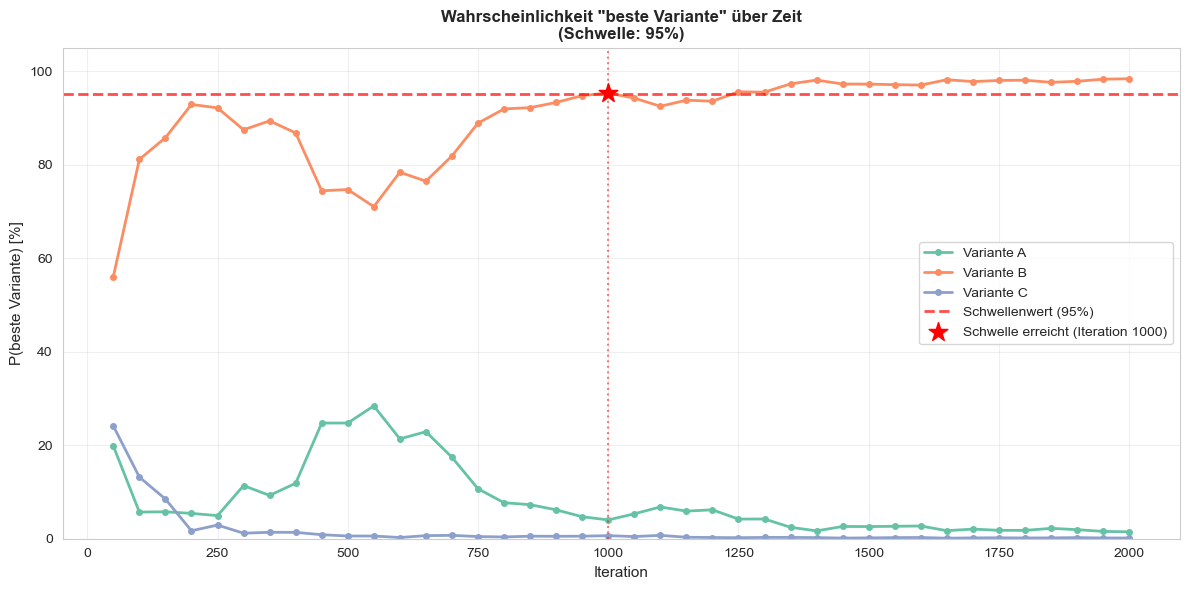


2. Evolution der Posterior-Verteilungen


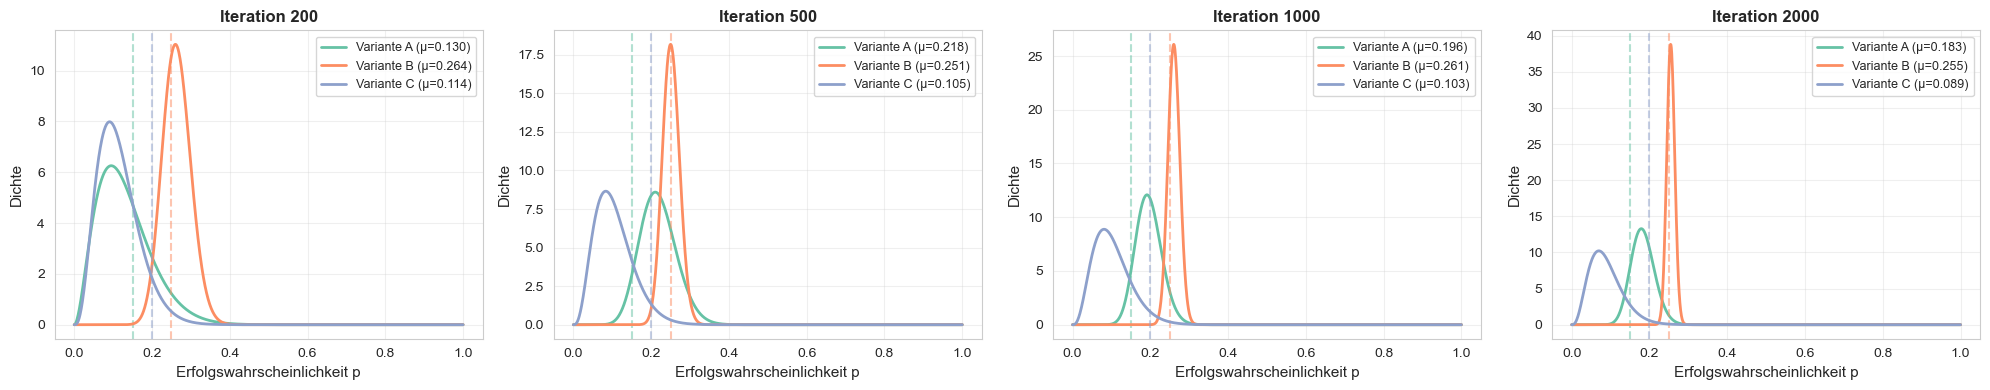


3. Arm-Auswahlen über Zeit


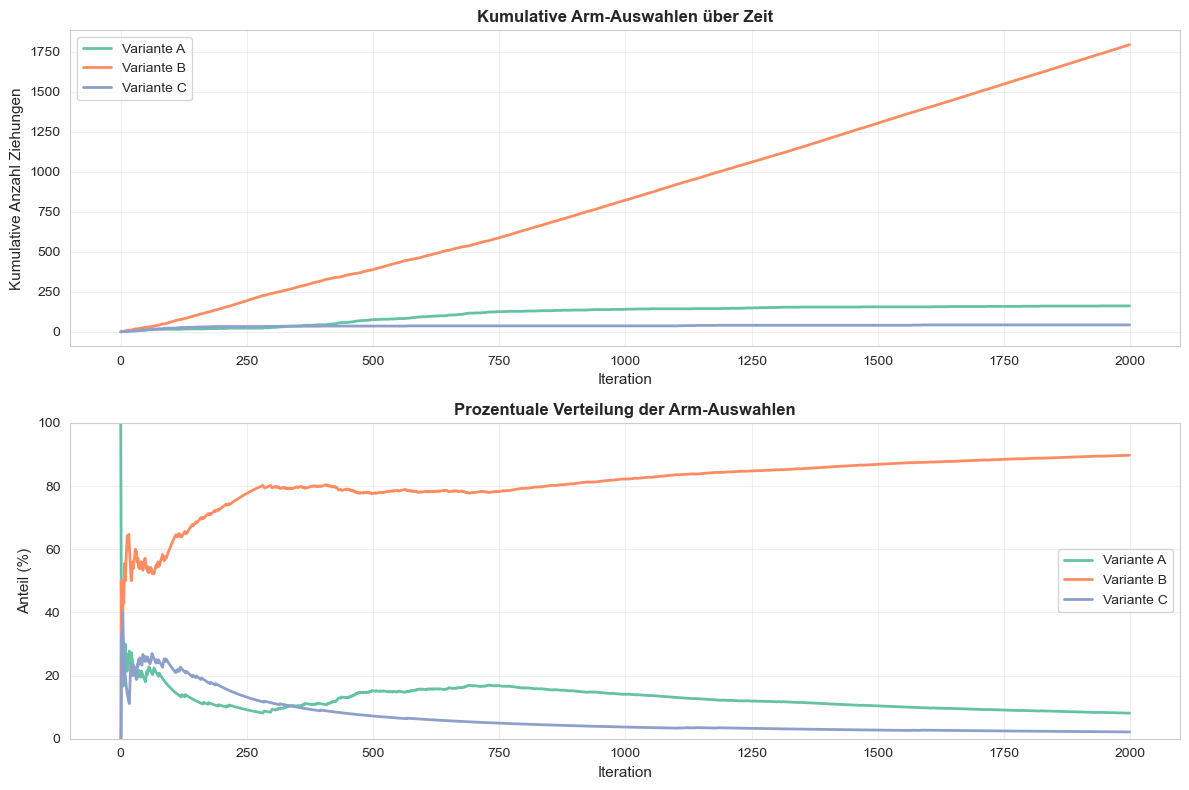


4. Posterior-Mittelwerte mit Konfidenzintervallen


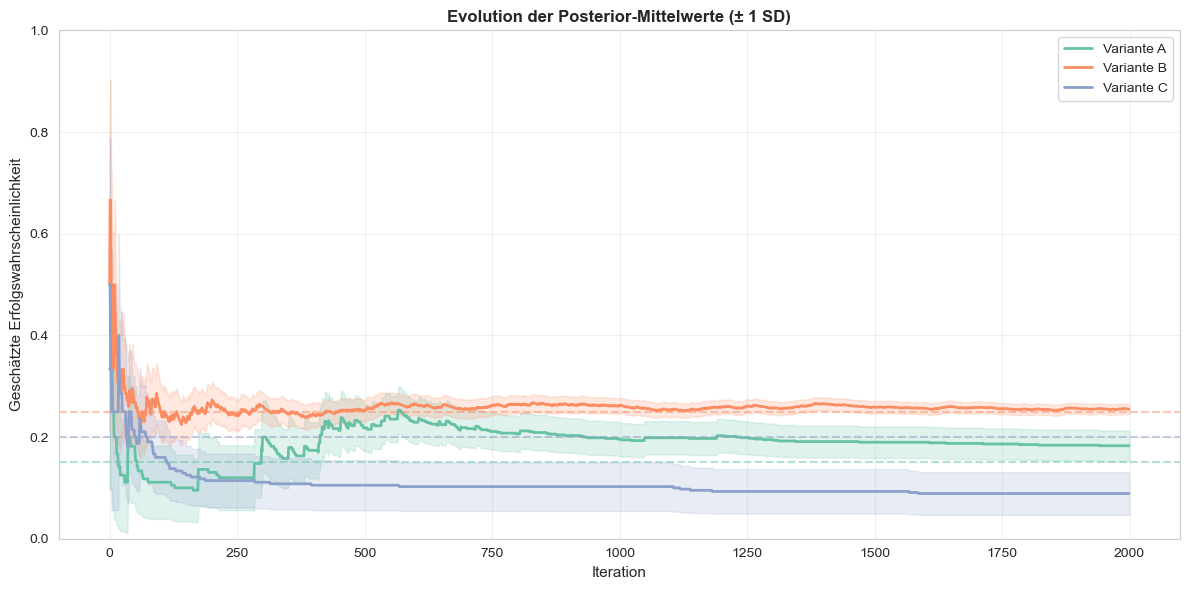


5. Kumulativer Regret


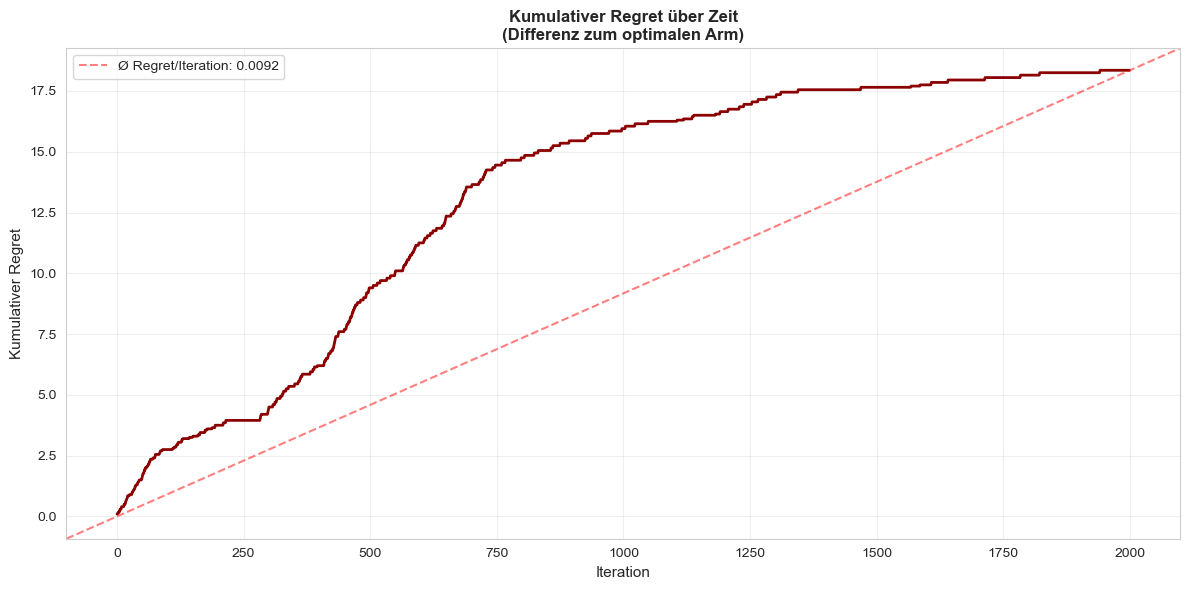

In [8]:
create_full_visualization(bandit, true_probabilities, tracking_info)

## 8. Interpretation der Ergebnisse

### Was passiert ist:

1. **Exploration Phase (erste ~200-300 Iterationen)**: 
   - Der Algorithmus testet alle Varianten mit relativ gleicher Häufigkeit
   - Die Posterior-Verteilungen werden schmaler, da mehr Daten gesammelt werden

2. **Exploitation Phase (danach)**:
   - Der Algorithmus erkennt, dass Variante B die höchste Erfolgswahrscheinlichkeit hat
   - Variante B bekommt zunehmend mehr Traffic (60-80%)
   - Varianten A und C werden weiterhin gelegentlich getestet (Exploration bleibt erhalten)

3. **Konvergenz**:
   - Die geschätzten Erfolgswahrscheinlichkeiten (Posterior-Mittelwerte) konvergieren zu den wahren Werten
   - Die Unsicherheit (Standardabweichung) nimmt mit mehr Daten ab
   - Der kumulative Regret wächst sublinear (Zeichen für effizienten Algorithmus)

4. **Konfidenz-Schwelle erreicht**:
   - Der Algorithmus trackt, ab welcher Iteration eine Variante mit der konfigurierten Konfidenz (z.B. 95%) die beste ist
   - Ab diesem Zeitpunkt kann man die probabilistische Aussage treffen: "Variante X ist mit Y% Wahrscheinlichkeit die beste"

### Vorteile gegenüber klassischem A/B-Test:

- ✅ **Keine feste Testphase**: Kontinuierliche Optimierung
- ✅ **Automatische Traffic-Allokation**: Mehr Besucher sehen die beste Variante
- ✅ **Minimierter Regret**: Weniger verlorene Conversions während des Tests
- ✅ **Flexible Anpassung**: Bei Änderungen der wahren Raten passt sich der Algorithmus an
- ✅ **Probabilistische Aussagen**: Kann präzise sagen, ab welcher Iteration eine Variante mit konfigurierbarer Konfidenz (z.B. 95%) die beste ist

### Was ist der "Kumulative Regret"?

Der **Regret** (Bedauern) ist eine zentrale Metrik zur Bewertung von Bandit-Algorithmen. Er misst den "Verlust" durch suboptimale Entscheidungen während des Lernprozesses.

#### Definition:

**Instant Regret** bei Iteration $t$:
$$r_t = p_{\text{best}} - p_{\text{gewählt}}$$

**Kumulativer Regret** nach $T$ Iterationen:
$$R(T) = \sum_{t=1}^{T} r_t = T \cdot p_{\text{best}} - \sum_{t=1}^{T} p_{\text{gewählt}_t}$$

**In Worten:**
- Bei jeder Iteration entsteht Regret, wenn wir **nicht** den besten Arm wählen
- Der Regret ist die **Differenz** zwischen der besten möglichen Erfolgswahrscheinlichkeit und der tatsächlich gewählten
- Der kumulative Regret summiert diese "Opportunitätskosten" über alle Iterationen

#### Interpretation der Visualisierung:

**Form der Kurve:**
- **Steiler Anstieg anfangs**: In der Exploration-Phase werden oft suboptimale Arme gewählt
- **Flacher werdend**: Sobald der Algorithmus die beste Variante identifiziert, wächst der Regret langsamer
- **Sublineares Wachstum** ($R(T) = O(\log T)$): Zeichen eines effizienten Algorithmus wie Thompson Sampling

**Die gestrichelte Linie** zeigt den durchschnittlichen Regret pro Iteration:
$$\text{Durchschnittlicher Regret} = \frac{R(T)}{T}$$

**Was ist gut?**
- ✅ **Sublineares Wachstum**: Regret wächst langsamer als linear → Algorithmus lernt!
- ✅ **Niedriger Endwert**: Wenige Opportunitätskosten während des Lernens
- ✅ **Flache Kurve im späteren Verlauf**: Algorithmus hat die beste Variante identifiziert

**Was wäre schlecht?**
- ❌ **Lineares Wachstum**: Algorithmus lernt nicht, wählt zufällig
- ❌ **Zu steile Kurve**: Zu viel Exploration, zu wenig Exploitation
- ❌ **Keine Abflachung**: Algorithmus konvergiert nicht

**Praktische Bedeutung:**

In unserem Beispiel mit Conversion-Raten bedeutet Regret:
- Wenn die beste Variante 25% Conversion hat und wir eine mit 15% wählen
- **→ Regret = 0.10 (10 Prozentpunkte)**
- **→ Bei 100 Besuchern: ~10 verlorene Conversions**

Der kumulative Regret über 2000 Iterationen zeigt uns die **Gesamtzahl der "verlorenen" Conversions** während der Lernphase. Thompson Sampling minimiert diesen Verlust durch intelligente Balance zwischen Exploration (Lernen) und Exploitation (Nutzen des Gelernten).

## 9. Verschiedene Konfidenz-Schwellen testen

Hier ein Beispiel, wie man verschiedene Konfidenz-Schwellen testen kann:

In [9]:
# Teste verschiedene Konfidenz-Schwellen
thresholds_to_test = [0.90, 0.95, 0.99]

print("Vergleich verschiedener Konfidenz-Schwellen:")
print("=" * 70)

for threshold in thresholds_to_test:
    bandit_test = BayesianBandit(n_arms=3, arm_names=arm_names)
    bandit_test, info_test = simulate_bandit(
        bandit_test, 
        true_probabilities, 
        n_iterations=2000, 
        random_seed=42,
        confidence_threshold=threshold,
        check_interval=50
    )
    
    print(f"\nSchwelle: {threshold:.0%}")
    if info_test['threshold_reached'] is not None:
        iter_reached, arm_idx = info_test['threshold_reached']
        print(f"  ✓ Erreicht bei Iteration {iter_reached} ({arm_names[arm_idx]})")
    else:
        print(f"  ✗ Nicht erreicht (benötigt mehr Iterationen)")

print("\n" + "=" * 70)
print("Fazit: Höhere Schwellen benötigen mehr Daten für eine sichere Aussage.")

Vergleich verschiedener Konfidenz-Schwellen:

Schwelle: 90%
  ✓ Erreicht bei Iteration 200 (Variante B)

Schwelle: 95%
  ✓ Erreicht bei Iteration 1000 (Variante B)

Schwelle: 99%
  ✗ Nicht erreicht (benötigt mehr Iterationen)

Fazit: Höhere Schwellen benötigen mehr Daten für eine sichere Aussage.


## 10. Erweiterungsmöglichkeiten

Dieser Code kann leicht erweitert werden:

1. **Mehr Varianten**: Einfach `n_arms` erhöhen und mehr Wahrscheinlichkeiten definieren
2. **Kontextuelle Bandits**: Verschiedene Beta-Parameter für verschiedene User-Segmente
3. **Non-Bernoulli Rewards**: Andere Reward-Verteilungen (z.B. kontinuierlich)
4. **Decay**: Vergesse alte Daten, um sich an Veränderungen anzupassen
5. **Andere Strategien**: UCB (Upper Confidence Bound), Epsilon-Greedy zum Vergleich

```python
# Beispiel: 5 Varianten mit 99%-Schwelle
true_probs_5 = np.array([0.10, 0.15, 0.25, 0.18, 0.12])
bandit_5 = BayesianBandit(n_arms=5, arm_names=[f'Var {i+1}' for i in range(5)])
bandit_5, info_5 = simulate_bandit(bandit_5, true_probs_5, 3000, random_seed=42, confidence_threshold=0.99)
bandit_5.print_summary()
print_threshold_analysis(bandit_5, info_5)
```